In [41]:
#setting wd
from google.colab import drive
drive.mount('/content/drive')

import os

os.chdir("/content/drive/MyDrive/Colab Notebooks/project")
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/Colab Notebooks/project'

In [42]:
import pandas as pd
import requests
import geopandas as gpd

overlay_gdf = gpd.read_file("data/raw/geo/tract_neighborhood_overlay.geojson")
neighborhoods_gdf = gpd.read_file("data/raw/geo/stl_neighborhoods.geojson")
fema_gdf = gpd.read_file("data/raw/geo/fema_flood_zones.geojson")

# 2024 ACS 5-year example
base_url = "https://api.census.gov/data/2024/acs/acs5"

In [43]:
# Missouri only; we will filter to St. Louis City (510) and St. Louis County (189)
params = {
    "get": ",".join([
        "NAME",
        "B19013_001E",  # median household income
        "B25070_001E",  # total renter households with gross rent as % of income
        "B25070_007E",  # 30.0 to 34.9 percent
        "B25070_008E",  # 35.0 to 39.9 percent
        "B25070_009E",  # 40.0 to 49.9 percent
        "B25070_010E",  # 50.0 percent or more
    ]),
    "for": "tract:*",
    "in": "state:29"
}

response = requests.get(base_url, params=params, timeout=60)
response.raise_for_status()

rows = response.json()
acs = pd.DataFrame(rows[1:], columns=rows[0])

# keep only St. Louis City + St. Louis County
acs = acs[acs["county"].isin(["510", "189"])].copy()

# make GEOID for joining to your tract overlay
acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]

# numeric conversion
num_cols = [
    "B19013_001E",
    "B25070_001E",
    "B25070_007E",
    "B25070_008E",
    "B25070_009E",
    "B25070_010E",
]
for col in num_cols:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")

# feature: % renter households spending >30% of income on gross rent
acs["housing_cost_burden_ratio"] = (
    acs["B25070_007E"]
    + acs["B25070_008E"]
    + acs["B25070_009E"]
    + acs["B25070_010E"]
) / acs["B25070_001E"]

# cleaner column names
acs = acs.rename(columns={
    "B19013_001E": "median_household_income",
    "B25070_001E": "rent_burden_total_households"
})

acs.head()

,NAME,median_household_income,rent_burden_total_households,B25070_007E,B25070_008E,B25070_009E,B25070_010E,state,county,tract,GEOID,housing_cost_burden_ratio
1199,Census Tract 2101.01; St. Louis County; Missouri,74306,100,0,23,0,8,29,189,210101,29189210101,0.310000
1200,Census Tract 2101.02; St. Louis County; Missouri,44107,645,132,22,143,225,29,189,210102,29189210102,0.809302
1201,Census Tract 2102; St. Louis County; Missouri,30298,1529,73,278,99,754,29,189,210200,29189210200,0.787443
1202,Census Tract 2103; St. Louis County; Missouri,55651,849,8,33,53,206,29,189,210300,29189210300,0.353357
1203,Census Tract 2104; St. Louis County; Missouri,58244,629,96,45,18,173,29,189,210400,29189210400,0.527822


In [44]:
from pathlib import Path

Path("data/raw/census").mkdir(parents=True, exist_ok=True)
acs.to_csv("data/raw/census/acs_tract_stl.csv", index=False)

In [45]:
overlay_gdf = overlay_gdf.merge(
    acs[["GEOID", "median_household_income", "housing_cost_burden_ratio"]],
    on="GEOID",
    how="left"
)

overlay_gdf

#importance: each row is a piece of a census tract overlapping a neighborhood

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,NHD_NUM,NHD_NAME,ANGLE,NHD_NUMTXT,NHD_NUM_ST,intersect_area,area_weight,geometry,median_household_income,housing_cost_burden_ratio
0,29,189,210200,29189210200,1400000US29189210200,2102,Census Tract 2102,G5020,S,4320753,...,75,Riverview,0.0,75 Riverview,None,4.032177e+02,0.000093,"MULTIPOLYGON (((-90.19281 38.75401, -90.19303 ...",30298,0.787443
1,29,510,115100,29510115100,1400000US29510115100,1151,Census Tract 1151,G5020,S,1145348,...,6,Princeton Heights,0.0,6 Princeton Heights,None,5.711141e+04,0.049834,"POLYGON ((-90.27853 38.58147, -90.27846 38.581...",47958,0.339921
2,29,510,115100,29510115100,1400000US29510115100,1151,Census Tract 1151,G5020,S,1145348,...,5,Bevo Mill,0.0,5 Bevo Mill,None,1.088546e+06,0.949842,"POLYGON ((-90.27659 38.58518, -90.27656 38.585...",47958,0.339921
3,29,510,110400,29510110400,1400000US29510110400,1104,Census Tract 1104,G5020,S,885192,...,59,Jeff Vanderlou,0.0,59 Jeff Vanderlou,None,7.230689e+05,0.816323,"POLYGON ((-90.22222 38.66353, -90.22181 38.663...",53075,0.267606
4,29,510,110400,29510110400,1400000US29510110400,1104,Census Tract 1104,G5020,S,885192,...,56,Greater Ville,0.0,56 Greater Ville,None,1.625748e+05,0.183542,"POLYGON ((-90.22866 38.65966, -90.22848 38.659...",53075,0.267606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417,29,510,112400,29510112400,1400000US29510112400,1124,Census Tract 1124,G5020,S,938488,...,53,Fountain Park,0.0,53 Fountain Park,None,2.656971e+00,0.000003,"POLYGON ((-90.26144 38.65143, -90.26135 38.651...",78185,0.365509
418,29,510,117200,29510117200,1400000US29510117200,1172,Census Tract 1172,G5020,S,1267491,...,29,Tiffany,0.0,29 Tiffany,None,3.827661e+02,0.000302,"POLYGON ((-90.24442 38.62129, -90.24448 38.620...",127772,0.229381
419,29,510,117200,29510117200,1400000US29510117200,1172,Census Tract 1172,G5020,S,1267491,...,28,Botanical Heights,0.0,28 Botanical Heights,None,2.229967e+05,0.175828,"POLYGON ((-90.25604 38.61828, -90.25596 38.618...",127772,0.229381
420,29,510,117200,29510117200,1400000US29510117200,1172,Census Tract 1172,G5020,S,1267491,...,27,Shaw,0.0,27 Shaw,None,1.043401e+06,0.822699,"POLYGON ((-90.25766 38.60992, -90.25764 38.61,...",127772,0.229381


In [46]:
overlay_gdf = overlay_gdf.dropna(subset=["NHD_NAME"])  # clean nulls

neighborhood_data = (
    overlay_gdf.groupby("NHD_NAME")
    .apply(lambda df: pd.Series({
        "income": (df["median_household_income"] * df["area_weight"]).sum() / df["area_weight"].sum(),
        "housing_cost_burden_ratio": (df["housing_cost_burden_ratio"] * df["area_weight"]).sum() / df["area_weight"].sum()
    }))
    .reset_index()
)

neighborhood_data.head()

/tmp/ipykernel_9608/2353414063.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,NHD_NAME,income,housing_cost_burden_ratio
0,Academy,45002.028696,0.501522
1,Baden,45272.158824,0.424325
2,Benton Park,91600.430676,0.294214
3,Benton Park West,50195.962851,0.514049
4,Bevo Mill,55713.512283,0.324973


In [47]:
#flood percentage per neighborhood
fema_join = gpd.overlay(fema_gdf, neighborhoods_gdf, how="intersection")

fema_join["flood_area"] = fema_join.geometry.area

neighborhoods_gdf["total_area"] = neighborhoods_gdf.geometry.area

flood_pct = (
    fema_join.groupby("NHD_NAME")["flood_area"].sum().reset_index()
)

flood_pct = flood_pct.merge(
    neighborhoods_gdf[["NHD_NAME", "total_area"]],
    on="NHD_NAME"
)

flood_pct["flood_zone_pct"] = flood_pct["flood_area"] / flood_pct["total_area"]

flood_pct.head()

/tmp/ipykernel_9608/3164338259.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fema_join["flood_area"] = fema_join.geometry.area
/tmp/ipykernel_9608/3164338259.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  neighborhoods_gdf["total_area"] = neighborhoods_gdf.geometry.area


,NHD_NAME,flood_area,total_area,flood_zone_pct
0,Academy,0.000120,0.000120,1.000000
1,Baden,0.000294,0.000294,0.998566
2,Benton Park,0.000128,0.000128,1.000000
3,Benton Park West,0.000109,0.000109,1.000000
4,Bevo Mill,0.000366,0.000366,1.000000


<Axes: >

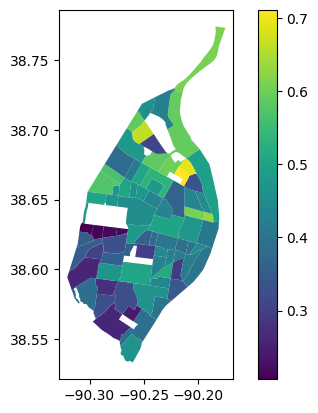

In [48]:
#combining everything +
final_df = neighborhood_data.merge(
    flood_pct[["NHD_NAME", "flood_zone_pct"]],
    on="NHD_NAME",
    how="left"
)

final_df.head()

neighborhoods_gdf = neighborhoods_gdf.merge(final_df, on="NHD_NAME")

neighborhoods_gdf.plot(column="housing_cost_burden_ratio", legend=True)

This map shows the housing cost burden ratio across St. Louis neighborhoods.
Higher values (yellow) indicate neighborhoods where a larger share of households
spend more than 30% of their income on housing. Lower values (purple) indicate
more affordable areas. The results were calculated using an area-weighted spatial
join between census tracts and neighborhood boundaries.

In [49]:
final_df.to_csv("data/raw/census/neighborhood_data.csv", index=False)

In [50]:
print("Number of neighborhoods:", len(final_df))

Number of neighborhoods: 79


All 79 neighborhoods have values after the spatial join.

